In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd
import glob

from bertopic import BERTopic
from bertopic.backend import MultiModalBackend
from bertopic.representation import VisualRepresentation, KeyBERTInspired

import umap


In [2]:
visual_model = VisualRepresentation()

representation_model = {
   "Visual_Aspect":  visual_model,
}
topic_model = BERTopic(representation_model=representation_model, verbose=True)
embedding_model = MultiModalBackend('clip-ViT-B-32', batch_size=32)

In [3]:
images = utils.get_files_in_directory("../../Data/STEREO_VIEWS/LEFT_IMAGE/")
images = images[1:]

In [4]:
# GET IMAGE CAPTIONS FROM BOOK
sentence_folders = utils.get_folders_in_folder("../../Data/TEXT/ALL_SENTENCES/")
all_captions = []
for folder in sentence_folders:
    all_paragraphs = utils.get_files_in_directory(folder + "/")
    first_paragraph = utils.read_file(all_paragraphs[0])
    caption = first_paragraph.split("\n")[0]
    if caption[0].isdigit():
        caption = ".".join(caption.split(".")[1:])
    all_captions.append(caption)

In [5]:

topic_model_captions = BERTopic(representation_model=representation_model, n_gram_range=(1,2), min_topic_size=3, verbose=True, embedding_model=embedding_model, umap_model=umap.UMAP(random_state=100))
topics_captions, probs_captions = topic_model_captions.fit_transform(documents=all_captions, images=images)

2025-06-25 09:46:10,121 - BERTopic - Embedding - Transforming documents to embeddings.
100%|██████████| 4/4 [00:58<00:00, 14.75s/it]
2025-06-25 09:47:10,614 - BERTopic - Embedding - Completed ✓
2025-06-25 09:47:10,615 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2025-06-25 09:47:16,648 - BERTopic - Dimensionality - Completed ✓
2025-06-25 09:47:16,648 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-25 09:47:16,657 - BERTopic - Cluster - Completed ✓
2025-06-25 09:47:16,659 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 10/10 [00:38<00:00,  3.81s/it]
2025-06-25 09:47:54,825 - BERTopic - Representation - Completed ✓


In [6]:
def get_images_per_topic():
    topic_to_image = dict()
    for t in range(-1, 9):
        topic_to_image[t] = []
        for i, c in enumerate(topics_captions):
            if c == t:
                topic_to_image[t].append(i)
    return topic_to_image

topic_to_image = get_images_per_topic()

In [8]:
freq = topic_model_captions.get_topic_info()
freq.head(15)

,Topic,Count,Name,Representation,Visual_Aspect,Representative_Docs
0,-1,27,-1_the_from_of_looking,"[the, from, of, looking, and, of the, canton, ...",<PIL.Image.Image image mode=RGB size=561x600 a...,[ Reminders of the Terrible Eight Weeks' Siege...
1,0,17,0_the_of_pekin_of the,"[the, of, pekin, of the, in, imperial, the imp...",<PIL.Image.Image image mode=RGB size=562x600 a...,[ Wan-Shou-Shan (Hill of Ten Thousand Ages) Su...
2,1,17,1_gate_the_south gate_south,"[gate, the, south gate, south, city, tsin, tie...",<PIL.Image.Image image mode=RGB size=561x600 a...,[ Motley Crowds and Jumbled Huts of Old Tien-t...
3,2,10,2_of_river_the_canal,"[of, river, the, canal, canal soo, canton, boa...",<PIL.Image.Image image mode=RGB size=561x600 a...,[ From the Imperial Bank of China (N.) along W...
4,3,10,3_of_the_with_of the,"[of, the, with, of the, pekin, powers, li, wom...",<PIL.Image.Image image mode=RGB size=559x600 a...,"[ ""King of the Beggars"" the Chief of a Beggar ..."
5,4,7,4_the_of_tien_tsin,"[the, of, tien, tsin, tien tsin, as, makers, t...",<PIL.Image.Image image mode=RGB size=336x600 a...,[ Some of China's Trouble-makers-Boxer Prisone...
6,5,3,5_canton_ku_of twelve_cells,"[canton, ku, of twelve, cells, cells where, ex...",<PIL.Image.Image image mode=RGB size=1680x600 ...,[ Panorama Northwest from the Northern Wall of...
7,6,3,6_presbyterian_gate presbyterian_mission schoo...,"[presbyterian, gate presbyterian, mission scho...",<PIL.Image.Image image mode=RGB size=1681x600 ...,[ Minister Conger leaving the Legation in His ...
8,7,3,7_boxers_the boxers_fleeing from_fleeing,"[boxers, the boxers, fleeing from, fleeing, fr...",<PIL.Image.Image image mode=RGB size=1683x600 ...,[ Missionary Refugees Fleeing from the Boxers....
9,8,3,8_by_from_to_british concession,"[by, from, to, british concession, destructive...",<PIL.Image.Image image mode=RGB size=1708x600 ...,"[ From Pilot's Tower, Looking North across the..."


In [11]:
data = pd.DataFrame(zip(freq.index.to_list(), freq.Count.to_list()), columns=["Cats", "Num"])

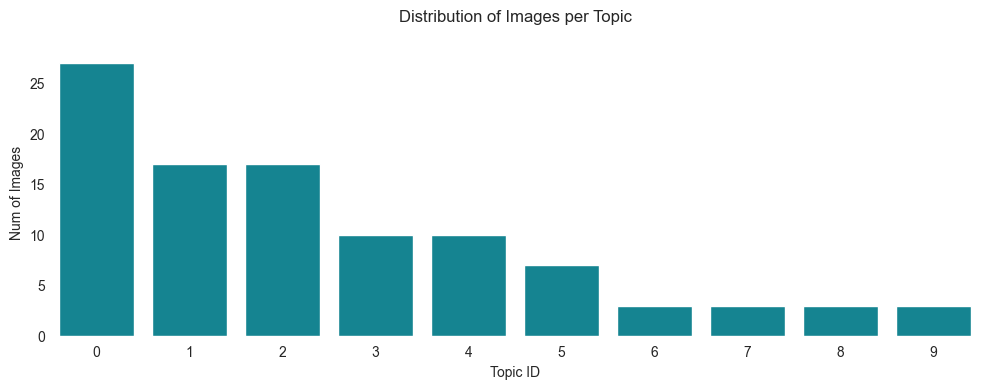

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Cats', y='Num', data=data,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Images')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Distribution of Images per Topic', pad=20)

plt.tight_layout()
plt.show()

In [30]:
import matplotlib.pyplot as plt
import math
import cv2

def display_class_images(class_id):
    sub_df = topic_to_image[class_id]
    for i, image in enumerate(sub_df):
        img = cv2.imread("../../Data/STEREO_VIEWS/LEFT_IMAGE/image_" + str(image+1) + ".png")
        print(image)
        plt.figure()
        plt.imshow(img)
    plt.show()

17
22
38
40
41
52
57
58
59
60
61
65
69
70
75
76
84


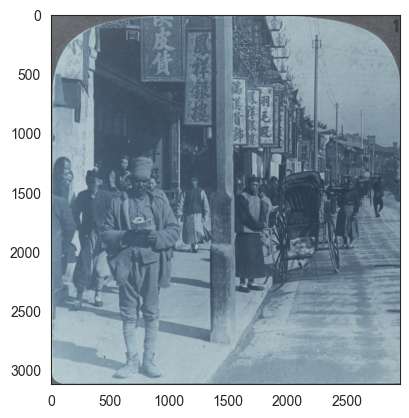

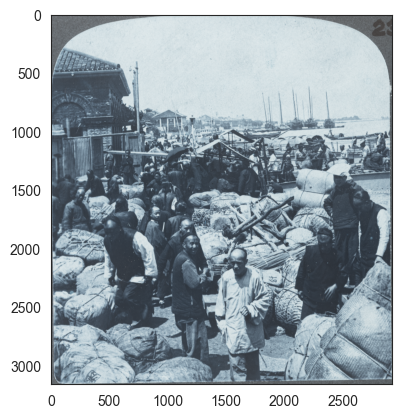

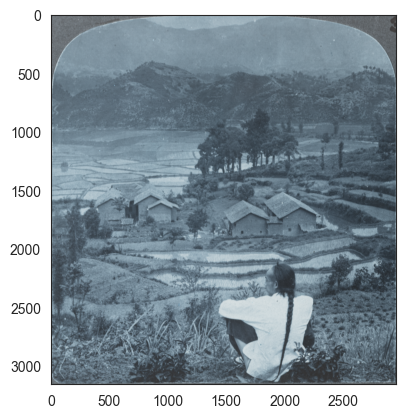

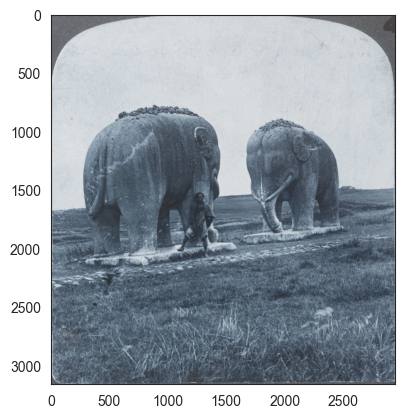

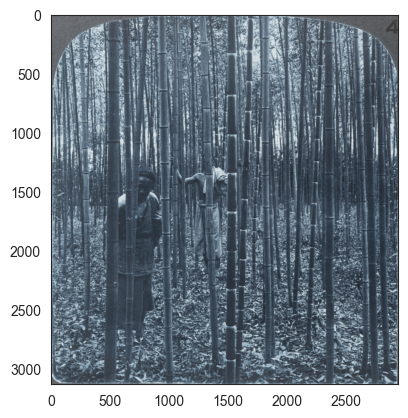

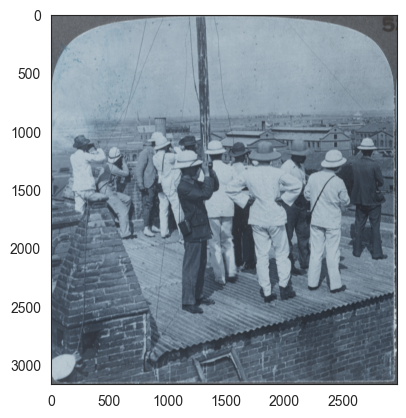

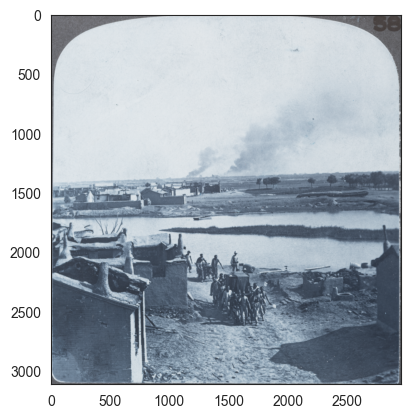

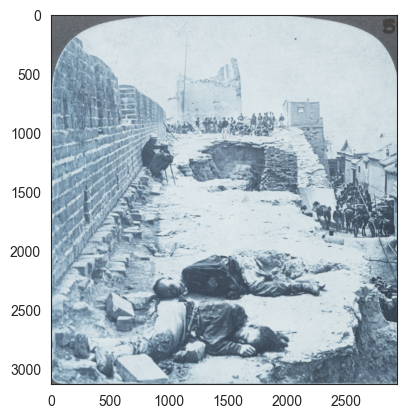

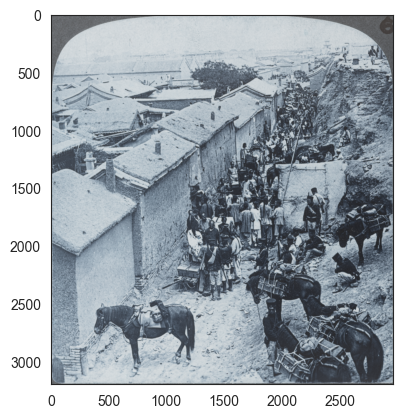

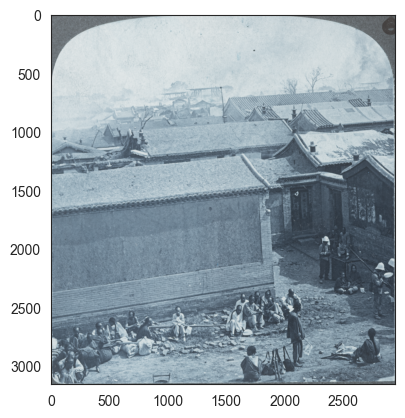

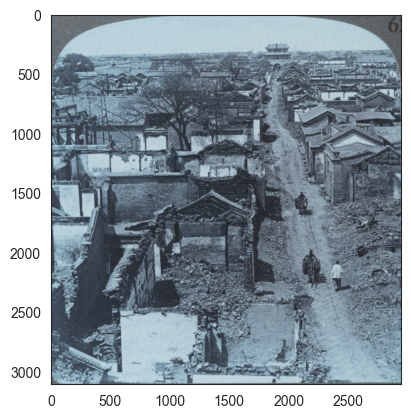

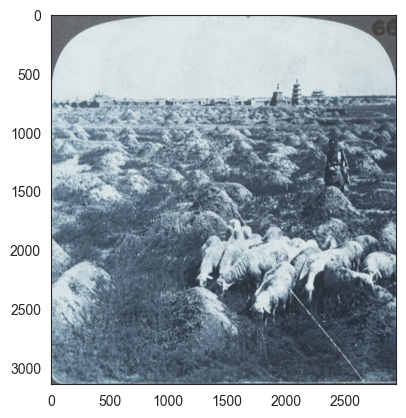

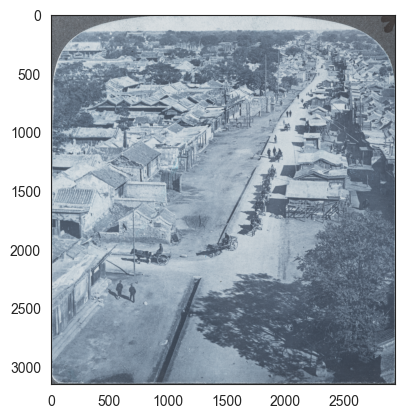

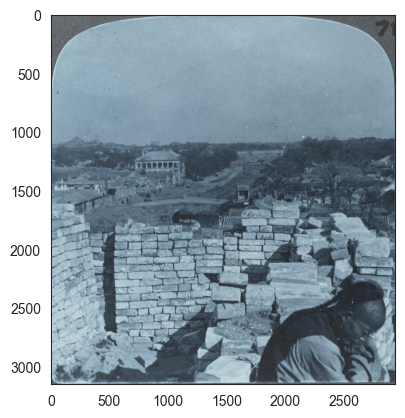

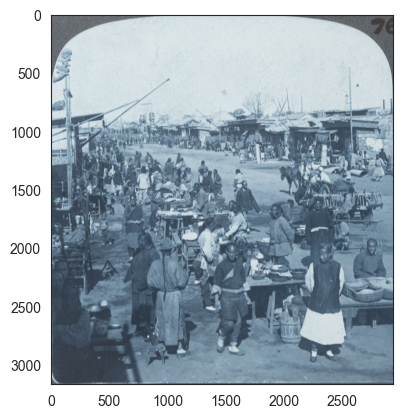

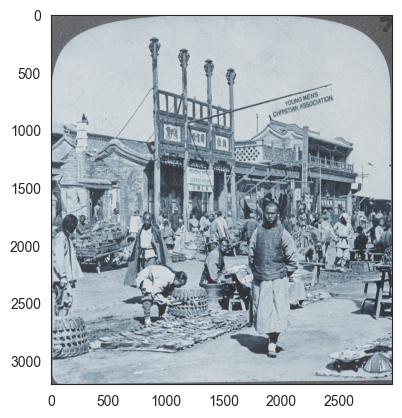

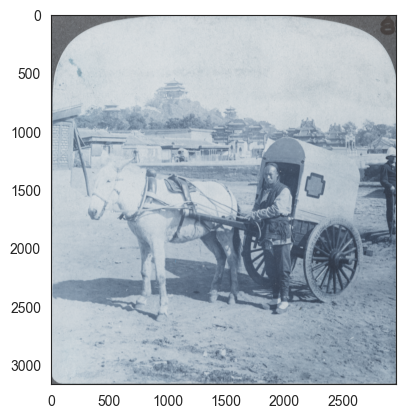

In [32]:
display_class_images(1)